# Try and Render Polygons in ASE; Gonna need projection matrices and shit. Then we're gonna try and create a z_stack that renders atoms and polyhedra in order based on their relative distance away from the camera. May split this into a separate notebook

['Ag', 'Ag', 'Ag', 'Ag', 'I', 'I', 'I', 'I']
[4 4 4 4 4 4 4 4]
[-3.47632058 -2.24157822  7.48723741]
yooo
yooo
yooo
yooo


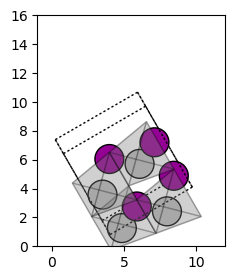

In [21]:
# -------------------------------------------------------------------- #
# Imports
from matplotlib.patches import Polygon
from ase.neighborlist import neighbor_list
from ase.visualize.plot import plot_atoms
from ase import Atoms
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.spatial import ConvexHull, convex_hull_plot_2d, Delaunay, delaunay_plot_2d
from scipy.spatial.transform import Rotation
from matplotlib.patches import Polygon
from ase.io import read

# -------------------------------------------------------------------- #
# Create supercell, set bounds
#supercell = Atoms(symbols='AgCl', pbc=True, positions=[[0,0,0], [0,2,1.578]], cell=[[-2.001241862062434, 2.001241862062434, 3.1564560000000017], [2.001241862062434, -2.001241862062434, 3.1564560000000017], [2.001241862062434, 2.001241862062434, -3.1564560000000017]])
supercell = read('POSCAR', format='vasp')
supercell = read('/projects/p32212/NewUserIsMe/FreeEnergy_Trials/AgI/Cubic_Tetragonal_PES/ABStrain_0.02/CStrain_0.00/POSCAR', format = 'vasp')

print(supercell.get_chemical_symbols())
supercell.set_pbc([1,1,1])
supercell = supercell.repeat([1,1,1])

supercell.rotate('x',10, center = 'COM', rotate_cell=True)
supercell.rotate('y',0, center = 'COM', rotate_cell=True)
supercell.rotate('z',30, center = 'COM', rotate_cell=True)

# Collect neighborlist according to a cutoff distance:
#bond_cutoff = 3
bond_cutoff = {('Ti', 'O'): 3, ('Sr', 'Ti'): 0.1, ('Sr', 'O'): 0.1}
bond_cutoff = {('Ag', 'I'): 5}

neighs, distances, shift = neighbor_list('iDS', supercell, bond_cutoff, self_interaction=False, max_nbins=1000000.0)
unique_neighs, unique_neigh_counts = np.unique(neighs, return_counts=True)

print(unique_neigh_counts)

# start plotting stuff; gonna need the projection matrices here:
fig, ax = plt.subplots(figsize=(3,3))
#polystack = np.empty((len(unique_neighs),np.max(unique_neigh_counts)))
plot_atoms(supercell, ax, rotation = '0x, 0y, 0z', radii = [1 for atom in supercell])
from ase.io.utils import PlottingVariables
pvars = PlottingVariables(supercell, scale=1.0)
r_vec = pvars.get_camera_right()
u_vec = pvars.get_camera_up()
print(pvars.offset)

for i in np.unique(neighs):
    if supercell.get_chemical_symbols()[i] == 'Ag':
        print('yooo')
    #if i == 4:
        origin = -1 * pvars.offset + supercell.get_positions()[i]
        poly = origin + distances[np.where(neighs == i)[0]]
        vertices = poly
        
        hull = ConvexHull(vertices)

        for e_ind, edge in enumerate(vertices[hull.simplices]):
            # project 3D coords into 2D based on some temporary image plane and basis:
            projection_plane_origin = [0,0,0] #distances[0] # set at closest atom for real
            projection_plane_basis = np.array([r_vec,u_vec])

            points_2D = projection_plane_basis @ (edge.T - projection_plane_origin)
            ax.add_patch(Polygon(xy = points_2D.T,
                            facecolor = 'grey',
                            edgecolor = 'black',
                            alpha = 0.2))

ax.set_xlim(-1, 12)
ax.set_ylim(0, 16)

plt.show()

In [2]:
print(supercell.get_center_of_mass())

[1.62406329 1.62406329 3.06274086]


# 3D to 2D Projection Trial

In [ ]:
points_3D = np.array([[1,0,0],[0,1,0],[0,0,1]])

projection_plane_origin = [-1,-1,-1]
projection_plane_basis = np.array([[1,-1,0],[0,0,1]])

points_2D = projection_plane_basis @ (points_3D - projection_plane_origin)

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(xs = points_3D[:,0], ys = points_3D[:,1], zs = points_3D[:,2])
ax.view_init(elev=45., azim=-45, roll=0)

fig, ax = plt.subplots()
print(points_2D)
ax.scatter(points_2D[0,:], points_2D[1,:])

In [ ]:
fig, ax = plt.subplots(figsize = (3,3))
ax.add_patch(Polygon(xy = points_2D.T,
                            facecolor = 'grey',
                            edgecolor = 'black',
                            alpha = 0.2,))
ax.set_xlim(-2,2)
ax.set_ylim(0,2)